## Most Optimal Skills For Data Analyst

In [130]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from ast import literal_eval

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:literal_eval(x) if pd.notna(x) else x)

In [131]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,python,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,r,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,alteryx,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,tableau,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
180,Data Analyst,Data Analyst III,"Dos Palos, CA",via My ArkLaMiss Jobs,Full-time,False,"California, United States",2023-02-27 13:00:39,False,True,United States,year,90250.0,NaN,California Health & Wellness,excel,"{'analyst_tools': ['excel', 'powerpoint']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,sql,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,vba,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,tableau,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,excel,"{'analyst_tools': ['tableau', 'excel', 'altery..."


In [132]:
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median','count'])
df_DA_US_group = df_DA_US_group.rename(columns={'count':'skill_count','median':'median_salary'})
df_DA_US_group.index = (df_DA_US_group.index .str.strip().str.upper())

In [133]:
DA_job_count = len(df_DA_US)
df_DA_US_group['percent'] =df_DA_US_group['skill_count'] / DA_job_count* 100
df_DA_US_group = df_DA_US_group.sort_values(by='percent',ascending=False)
percent=5
df_DA_skills_demand = df_DA_US_group[df_DA_US_group['percent'] > percent]
df_DA_skills_demand

,median_salary,skill_count,percent
job_skills,,,
SQL,91000.0,2508,14.380734
EXCEL,84392.0,1808,10.366972
PYTHON,97500.0,1431,8.205275
TABLEAU,92875.0,1364,7.821101
SAS,90000.0,926,5.309633
R,92500.0,893,5.120413


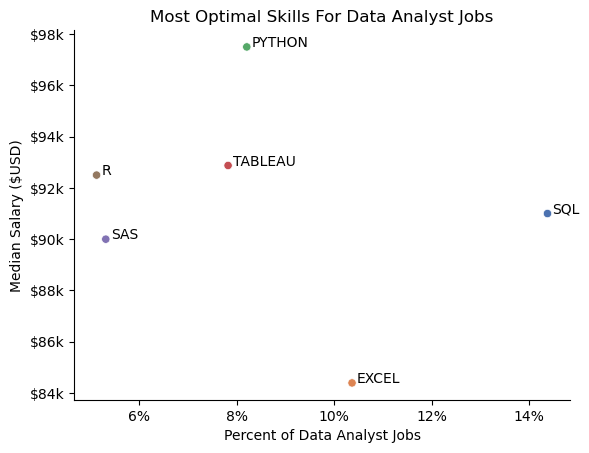

In [134]:
sns.scatterplot(data=df_DA_skills_demand,x='percent',y='median_salary',hue='job_skills',palette='deep',legend=False)

for i,txt in enumerate(df_DA_skills_demand.index):
    plt.text(df_DA_skills_demand['percent'].iloc[i]+.1,df_DA_skills_demand['median_salary'].iloc[i],txt)
plt.title('Most Optimal Skills For Data Analyst Jobs')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
ax=plt.gca()

from matplotlib.ticker import PercentFormatter
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
#ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos: f'{x}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos: f'${int(x/1000)}k'))

sns.despine()
plt.show()


In [160]:
df_technology = df['job_type_skills'].copy()

#remove duplicates

df_technology = df_technology.drop_duplicates()

#remove NA Values

df_technology = df_technology.dropna()

#combine all dictionaries into one
technology_dict={}
for row in df_technology:
    row_dict = literal_eval(row)   # string → dict
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key].extend(value)
        else:
            technology_dict[key] = value.copy()

# clean + deduplicate EACH key properly
for key, value in technology_dict.items():
    technology_dict[key] = list(
        {
            v.strip().upper()    # normalize
            for v in value
            if isinstance(v, str)
        }
    )


technology_dict




{'analyst_tools': ['OUTLOOK',
  'MICROSTRATEGY',
  'EXCEL',
  'TABLEAU',
  'VISIO',
  'DAX',
  'DATAROBOT',
  'MS ACCESS',
  'POWERBI',
  'ESQUISSE',
  'SPLUNK',
  'NUIX',
  'POWERPOINT',
  'SAS',
  'SAP',
  'SPSS',
  'LOOKER',
  'MSACCESS',
  'SSIS',
  'SSRS',
  'SHEETS',
  'ALTERYX',
  'SHAREPOINT',
  'SPREADSHEET',
  'QLIK',
  'POWER BI',
  'WORD',
  'COGNOS'],
 'programming': ['CLOJURE',
  'BASH',
  'F#',
  'SASS',
  'SWIFT',
  'RUBY',
  'OCAML',
  'SQL',
  'ERLANG',
  'JAVA',
  'PYTHON',
  'APL',
  'FORTRAN',
  'MONGO',
  'T-SQL',
  'DART',
  'LISP',
  'LUA',
  'C#',
  'JAVASCRIPT',
  'HTML',
  'KOTLIN',
  'VBA',
  'SHELL',
  'TYPESCRIPT',
  'JULIA',
  'COBOL',
  'POWERSHELL',
  'RUST',
  'C++',
  'GROOVY',
  'ASSEMBLY',
  'VISUALBASIC',
  'C',
  'SAS',
  'CRYSTAL',
  'VISUAL BASIC',
  'ELIXIR',
  'R',
  'OBJECTIVE-C',
  'DELPHI',
  'NOSQL',
  'GO',
  'VB.NET',
  'CSS',
  'HASKELL',
  'PHP',
  'GOLANG',
  'SOLIDITY',
  'PERL',
  'NO-SQL',
  'PASCAL',
  'SCALA',
  'MONGODB',
  'MAT

In [136]:
df_technology_dict = pd.DataFrame(list(technology_dict.items()) ,columns = ['technology','job_skills'])
df_technology_dict = df_technology_dict.explode('job_skills')
df_technology_dict

,technology,job_skills
0,analyst_tools,OUTLOOK
0,analyst_tools,MICROSTRATEGY
0,analyst_tools,EXCEL
0,analyst_tools,TABLEAU
0,analyst_tools,VISIO
...,...,...
9,sync,ZOOM
9,sync,GOOGLE CHAT
9,sync,SLACK
9,sync,WEBEX


In [137]:
df_plot = df_DA_skills_demand.merge(df_technology_dict,on='job_skills')
df_plot = df_plot.sort_values(by='percent',ascending=False)

df_plot

,job_skills,median_salary,skill_count,percent,technology
0,SQL,91000.0,2508,14.380734,programming
1,EXCEL,84392.0,1808,10.366972,analyst_tools
2,PYTHON,97500.0,1431,8.205275,programming
3,TABLEAU,92875.0,1364,7.821101,analyst_tools
4,SAS,90000.0,926,5.309633,analyst_tools
5,SAS,90000.0,926,5.309633,programming
6,R,92500.0,893,5.120413,programming


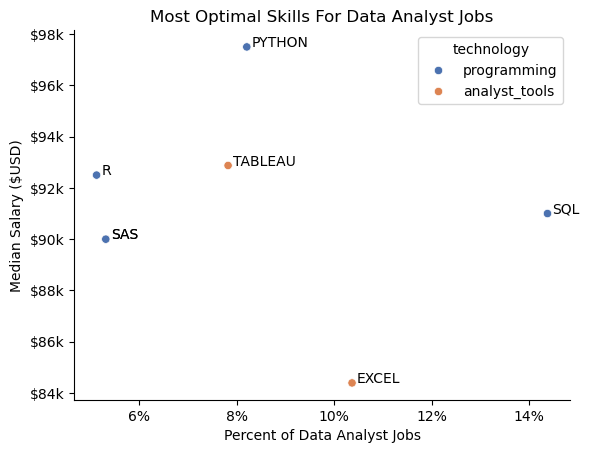

In [161]:
sns.scatterplot(data=df_plot,x='percent',y='median_salary',hue='technology',palette='deep')

for i,txt in enumerate(df_plot['job_skills']):
    plt.text(df_plot['percent'].iloc[i]+.1,df_plot['median_salary'].iloc[i],txt)
plt.title('Most Optimal Skills For Data Analyst Jobs')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
ax=plt.gca()

from matplotlib.ticker import PercentFormatter
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
#ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos: f'{x}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos: f'${int(x/1000)}k'))

sns.despine()
plt.show()